## **ASSIGNMENT-2**

## **Name=ADITYA GUPTA**

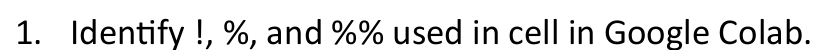

In [ ]:
print('''In Google Colab, these prefixes are used to interact with the environment:
!: Used for executing single-line shell commands, such as !ls or !nvidia-smi.
%: Used for Line Magics, which are commands that apply only to a single line of code.
%%: Used for Cell Magics, which apply to the entire content of the cell (e.g., %%cu or %%writefile).''')

In Google Colab, these prefixes are used to interact with the environment:
!: Used for executing single-line shell commands, such as !ls or !nvidia-smi.
%: Used for Line Magics, which are commands that apply only to a single line of code.
%%: Used for Cell Magics, which apply to the entire content of the cell (e.g., %%cu or %%writefile).


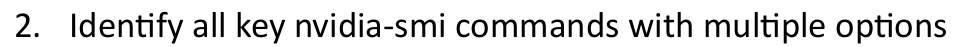

In [ ]:
print('''The NVIDIA System Management Interface (nvidia-smi) provides several options for GPU management:
nvidia-smi: Basic summary of GPU utilization and memory.
nvidia-smi -L: Lists all available GPUs on the system.
nvidia-smi -q: Provides a detailed query of all GPU attributes.
nvidia-smi -i <index>: Targets a specific GPU device by its index.''')

The NVIDIA System Management Interface (nvidia-smi) provides several options for GPU management:
nvidia-smi: Basic summary of GPU utilization and memory.
nvidia-smi -L: Lists all available GPUs on the system.
nvidia-smi -q: Provides a detailed query of all GPU attributes.
nvidia-smi -i <index>: Targets a specific GPU device by its index.


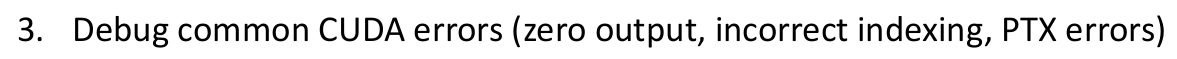

In [ ]:
print('''Typical errors encountered during CUDA development include:
Zero Output: Often caused by the CPU finishing before the GPU kernel completes. Fix: Use cudaDeviceSynchronize() after the kernel launch.
Incorrect Indexing: Leads to illegal memory access or incorrect data. Fix: Double-check the global thread ID formula: blockIdx.x * blockDim.x + threadIdx.x.+1
PTX Errors: Occur when compiled code is incompatible with the GPU architecture. Fix: Ensure the architecture flag (e.g., -arch=sm_xx) matches your hardware.''')

Typical errors encountered during CUDA development include:
Zero Output: Often caused by the CPU finishing before the GPU kernel completes. Fix: Use cudaDeviceSynchronize() after the kernel launch.
Incorrect Indexing: Leads to illegal memory access or incorrect data. Fix: Double-check the global thread ID formula: blockIdx.x * blockDim.x + threadIdx.x.+1
PTX Errors: Occur when compiled code is incompatible with the GPU architecture. Fix: Ensure the architecture flag (e.g., -arch=sm_xx) matches your hardware.


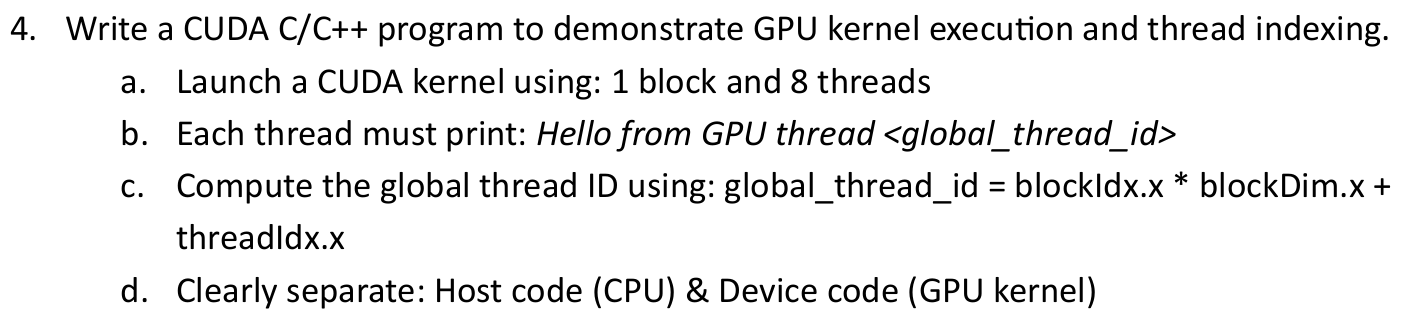

In [ ]:
%%writefile p1.cu

#include <iostream>
#include <cuda_runtime.h>

__global__ void helloKernel() {
    int global_thread_id = blockIdx.x * blockDim.x + threadIdx.x;
    printf("Hello from GPU thread %d\n", global_thread_id);
}

int main() {
    helloKernel<<<1, 8>>>();
    cudaDeviceSynchronize();
    return 0;
}

Writing p1.cu


In [ ]:
! ./p1.cu

/bin/bash: line 1: ./p1.cu: Permission denied


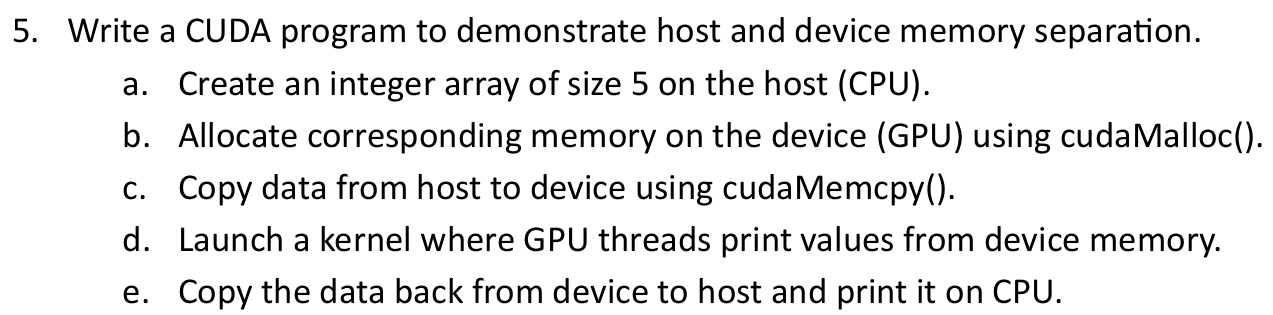

In [ ]:
%%writefile p2.cu

#include <iostream>
#include <cuda_runtime.h>

__global__ void printArrayKernel(int* d_arr) {
    int tid = threadIdx.x;
    printf("GPU thread %d sees value: %d\n", tid, d_arr[tid]);
}

int main() {
    const int SIZE = 5;
    int h_arr[SIZE] = {1, 2, 3, 4, 5};
    int *d_arr;

    cudaMalloc((void**)&d_arr, SIZE * sizeof(int));

    cudaMemcpy(d_arr, h_arr, SIZE * sizeof(int), cudaMemcpyHostToDevice);

    printArrayKernel<<<1, SIZE>>>(d_arr);
    cudaDeviceSynchronize();

    int h_result[SIZE];
    cudaMemcpy(h_result, d_arr, SIZE * sizeof(int), cudaMemcpyDeviceToHost);

    printf("Data back on CPU: ");
    for(int i=0; i<SIZE; i++) printf("%d ", h_result[i]);
    printf("\n");

    cudaFree(d_arr);
    return 0;
}

Writing p2.cu


In [ ]:
! ./p2.cu

/bin/bash: line 1: ./p2.cu: Permission denied


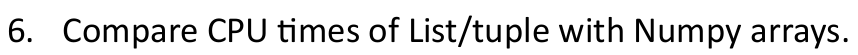

In [ ]:
import numpy as np
import time

size = 1000000

# Testing List time
my_list = list(range(size))
start = time.time()
list_sum = sum(my_list)
print(f"List execution time: {time.time() - start:.5f}s")
a=time.time() - start

# Testing Numpy array time
my_arr = np.arange(size)
start = time.time()
numpy_sum = np.sum(my_arr)
print(f"Numpy execution time: {time.time() - start:.5f}s")
b=time.time() - start
if a>b: print("Numpy is faster")
else: print("List is faster")

List execution time: 0.00990s
Numpy execution time: 0.00126s
Numpy is faster
